# 03 Metadata Baseline

Goal: verify the grouped train/validation split and run simple metadata-only baselines for `Acceptable` vs `Unacceptable`.

Important: the default metadata feature list deliberately excludes nitrate, phosphate, feedback text, scores, exact location, date/time, and participant count.

In [1]:
2

2

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'audited_metadata_with_split.csv'

SAFE_METADATA_FEATURES = [
    'Freshwater body type',
    'What is the main land use within 50m?',
    'What is the main bank vegetation? (select all that apply)',
    'Is there any of the following on the water surface?',
    'Estimate the water colour',
]

LEAKY_SANITY_FEATURES = [
    'Nitrate (mg/L)',
    'Phosphate (mg/L)',
]

TARGET = 'binary_label'
TARGET_NAMES = ['Acceptable', 'Unacceptable']

df = pd.read_csv(DATA_PATH, low_memory=False)
df['binary_label'] = df['binary_label'].astype(int)
df.shape

(9004, 161)

## Split And Label Checks

In [5]:
print(df['split'].value_counts())
print()
print(pd.crosstab(df['split'], df['binary_label_name']))
print()
print(pd.crosstab(df['split'], df['Feedback Rating']))

train_groups = set(df.loc[df['split'].eq('train'), 'GlobalID'])
val_groups = set(df.loc[df['split'].eq('val'), 'GlobalID'])
print('\nOverlapping GlobalIDs:', len(train_groups & val_groups))

split
train    7207
val      1797
Name: count, dtype: int64

binary_label_name  Acceptable  Unacceptable
split                                      
train                    2633          4574
val                       626          1171

Feedback Rating  Good  Moderate  Poor
split                                
train            2633      1496  3078
val               626       376   795

Overlapping GlobalIDs: 0


In [6]:
feature_summary = pd.DataFrame({
    'missing_pct': df[SAFE_METADATA_FEATURES].isna().mean().mul(100).round(1),
    'unique_values': df[SAFE_METADATA_FEATURES].nunique(dropna=True),
})
feature_summary

,missing_pct,unique_values
Freshwater body type,0.0,8
What is the main land use within 50m?,0.2,10
What is the main bank vegetation? (select all that apply),1.1,69
Is there any of the following on the water surface?,82.1,31
Estimate the water colour,0.0,7


In [7]:
for feature in SAFE_METADATA_FEATURES:
    print(f'\n## {feature}')
    display(df[feature].value_counts(dropna=False).head(15).to_frame('count'))


## Freshwater body type


,count
Freshwater body type,
River,4959
Stream,2979
Lake,329
Pond,264
Canal,239
Other,132
Ditch,88
Wetland,14



## What is the main land use within 50m?


,count
What is the main land use within 50m?,
Rural_residential,1498
Urban_green_space,1483
Urban_residential,1338
Mixed_agricultural,1024
Livestock,991
Grassland_shrub,859
Arable_agricultural,550
Other,526
Forest,444



## What is the main bank vegetation? (select all that apply)


,count
What is the main bank vegetation? (select all that apply),
Trees_shrubs,2577
"Trees_shrubs,Grass_small_plants",2191
Grass_small_plants,1484
"Trees_shrubs,Grass_small_plants,Bare_soil",678
"Trees_shrubs,Grass_small_plants,Concrete_impermeable_surface",438
Concrete_impermeable_surface,299
"Trees_shrubs,Grass_small_plants,Bare_soil,Concrete_impermeable_surface",183
"Grass_small_plants,Trees_shrubs",168
"Trees_shrubs,Bare_soil",115



## Is there any of the following on the water surface?


,count
Is there any of the following on the water surface?,
NaN,7396
Foam,601
Floating_algae,445
Slurry,211
Oily_sheen,117
"Foam,Floating_algae",39
"Floating_algae,Slurry",33
"Foam,Slurry",23
"Foam,None",21



## Estimate the water colour


,count
Estimate the water colour,
Colourless,5381
Brown,2241
Green,646
Yellow,321
Grey,202
Other,155
White_milky,58


## Helper Functions

In [8]:
train_df = df[df['split'].eq('train')].copy()
val_df = df[df['split'].eq('val')].copy()

y_train = train_df[TARGET]
y_val = val_df[TARGET]

def evaluate_model(name, model, X_val):
    pred = model.predict(X_val)
    print(f'## {name}')
    print('Balanced accuracy:', round(balanced_accuracy_score(y_val, pred), 4))
    print('Macro F1:', round(f1_score(y_val, pred, average='macro'), 4))
    print()
    print(classification_report(y_val, pred, target_names=TARGET_NAMES, zero_division=0))
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
    disp.plot(values_format='d', cmap='Blues')
    plt.title(name)
    plt.show()
    return pred

def make_categorical_logreg(features):
    preprocess = ColumnTransformer(
        transformers=[
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), features),
        ]
    )
    return Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ])

## Majority-Class Baseline

## Majority class baseline
Balanced accuracy: 0.5
Macro F1: 0.3945

              precision    recall  f1-score   support

  Acceptable       0.00      0.00      0.00       626
Unacceptable       0.65      1.00      0.79      1171

    accuracy                           0.65      1797
   macro avg       0.33      0.50      0.39      1797
weighted avg       0.42      0.65      0.51      1797



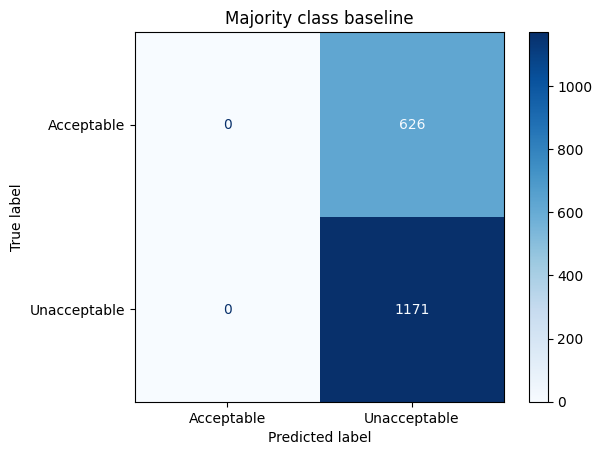

In [9]:
majority = DummyClassifier(strategy='most_frequent')
majority.fit(train_df[SAFE_METADATA_FEATURES], y_train)
_ = evaluate_model('Majority class baseline', majority, val_df[SAFE_METADATA_FEATURES])

## Safe Metadata Baseline

This is the baseline to report first. If this suddenly scores around 90%, check for leakage.

## Safe metadata logistic regression
Balanced accuracy: 0.6077
Macro F1: 0.6002

              precision    recall  f1-score   support

  Acceptable       0.46      0.56      0.51       626
Unacceptable       0.74      0.65      0.69      1171

    accuracy                           0.62      1797
   macro avg       0.60      0.61      0.60      1797
weighted avg       0.64      0.62      0.63      1797



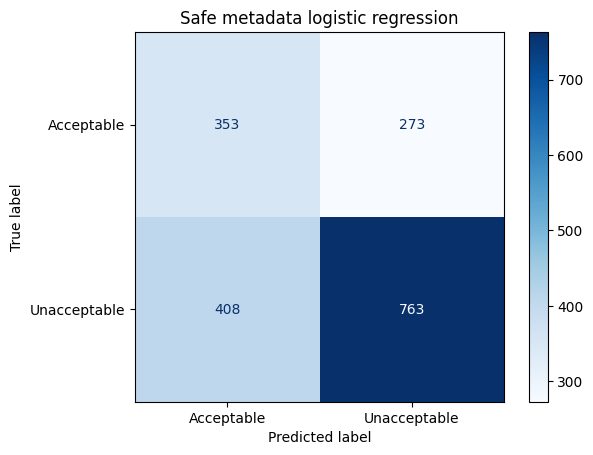

In [10]:
metadata_model = make_categorical_logreg(SAFE_METADATA_FEATURES)
metadata_model.fit(train_df[SAFE_METADATA_FEATURES], y_train)
safe_pred = evaluate_model('Safe metadata logistic regression', metadata_model, val_df[SAFE_METADATA_FEATURES])

In [11]:
onehot = metadata_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
feature_names = onehot.get_feature_names_out(SAFE_METADATA_FEATURES)
coefs = metadata_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})

display(coef_df.sort_values('coefficient', ascending=False).head(20))
display(coef_df.sort_values('coefficient').head(20))

,feature,coefficient
33,What is the main bank vegetation? (select all ...,0.920496
73,What is the main bank vegetation? (select all ...,0.918108
95,Is there any of the following on the water sur...,0.826792
86,Is there any of the following on the water sur...,0.713216
8,What is the main land use within 50m?_Arable_a...,0.688947
1,Freshwater body type_Ditch,0.673590
5,Freshwater body type_River,0.617165
60,What is the main bank vegetation? (select all ...,0.604836
107,Is there any of the following on the water sur...,0.590929
36,What is the main bank vegetation? (select all ...,0.517456


,feature,coefficient
37,What is the main bank vegetation? (select all ...,-1.159603
2,Freshwater body type_Lake,-1.088422
9,What is the main land use within 50m?_Forest,-0.962408
51,What is the main bank vegetation? (select all ...,-0.953100
65,What is the main bank vegetation? (select all ...,-0.952829
90,Is there any of the following on the water sur...,-0.950158
99,Is there any of the following on the water sur...,-0.831785
77,What is the main bank vegetation? (select all ...,-0.810309
4,Freshwater body type_Pond,-0.768538
111,Is there any of the following on the water sur...,-0.669981


## Leaky Sanity Check

This intentionally uses nitrate/phosphate. It should be very high because the label is effectively derived from these fields. Do not use this as the real metadata baseline.

## Leaky nitrate/phosphate sanity check
Balanced accuracy: 0.9996
Macro F1: 0.9994

              precision    recall  f1-score   support

  Acceptable       1.00      1.00      1.00       626
Unacceptable       1.00      1.00      1.00      1171

    accuracy                           1.00      1797
   macro avg       1.00      1.00      1.00      1797
weighted avg       1.00      1.00      1.00      1797



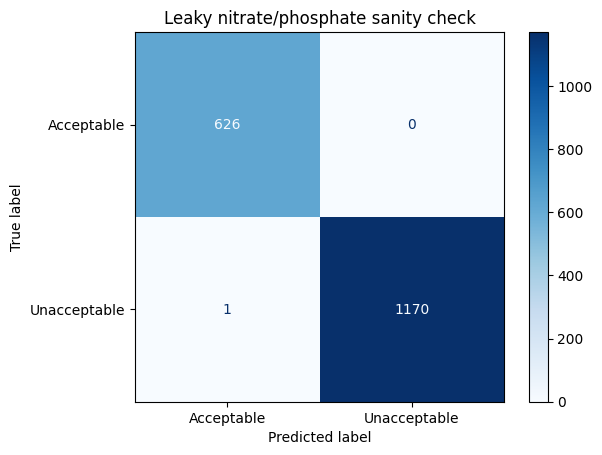

In [12]:
leaky_model = make_categorical_logreg(LEAKY_SANITY_FEATURES)
leaky_model.fit(train_df[LEAKY_SANITY_FEATURES], y_train)
_ = evaluate_model('Leaky nitrate/phosphate sanity check', leaky_model, val_df[LEAKY_SANITY_FEATURES])